In [61]:
# ============================================================================
# CELL 1: Imports & Setup
# ============================================================================
%matplotlib inline
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium import plugins
from pathlib import Path
import sys
import json
import joblib
from datetime import datetime
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
# Add src to path
sys.path.insert(0, str(Path.cwd().parent.parent))
from src.data import get_data_paths, DOMAIN_ITEMS
# Configure plots
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 300  # High resolution for thesis
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("✅ Imports successful")
print(f"✅ GeoPandas: {gpd.__version__}")
print(f"✅ Folium: {folium.__version__}")
# Get paths
paths = get_data_paths()
print(f"\n📁 Project: {paths['root']}")
print(f"📁 Geo: {paths['geo']}")
print(f"📁 Processed: {paths['processed']}")
print(f"📁 Reports/Outputs: {paths['reports'] / 'outputs'}")
# Ensure reports/outputs directory exists (FIX: Save map where dashboard expects it)
(paths['reports'] / 'outputs').mkdir(parents=True, exist_ok=True)

✅ Imports successful
✅ GeoPandas: 1.1.2
✅ Folium: 0.15.1

📁 Project: /Users/collinsbiwott/Desktop/ecd_final_ml
📁 Geo: /Users/collinsbiwott/Desktop/ecd_final_ml/geo
📁 Processed: /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed
📁 Reports/Outputs: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/outputs


In [62]:
# ============================================================================
# CELL 2: Load Data & Generate Predictions
# ============================================================================
print("\n🔹 Loading Data & Generating Predictions")
print("="*70)
# Load modeling dataset
modeling_data_path = paths['processed'] / 'kdhs_modeling_ready.parquet'
if modeling_data_path.exists():
    df = pd.read_parquet(modeling_data_path)
    print(f"✅ Loaded modeling data: {df.shape}")
else:
    df = pd.read_parquet(paths['interim'] / 'kr_clean.parquet')
    print(f"✅ Loaded interim data: {df.shape}")
# Load trained model for predictions
model_path = paths['models'] / 'prediction_pipeline_final.pkl'
if model_path.exists():
    pipeline = joblib.load(model_path)
    model = pipeline['model']
    scaler = pipeline.get('scaler', None)
    feature_cols = pipeline['feature_cols']
    print(f"✅ Loaded model: {pipeline.get('model_name', 'Unknown')}")
    # Generate predictions
    print("\n🔄 Generating predictions...")
    X = df[feature_cols].copy()
    if scaler is not None:
        X_scaled = scaler.transform(X)
        df['predicted_risk'] = model.predict_proba(X_scaled)[:, 1]
    else:
        df['predicted_risk'] = model.predict_proba(X)[:, 1]
    df['predicted_delay'] = (df['predicted_risk'] >= 0.5).astype(int)
    print(f"✅ Predictions generated: {df['predicted_delay'].sum()} delayed ({df['predicted_delay'].mean():.1%})")
else:
    # Fallback: use existing ecd_delay_composite
    print("⚠️  Model not found, using existing ecd_delay_composite")
    df['predicted_risk'] = df['ecd_delay_composite']
    df['predicted_delay'] = df['ecd_delay_composite']
# Check county column
county_col = 'county' if 'county' in df.columns else df.columns[0]
print(f"\n✅ County column: '{county_col}'")
print(f"📋 Unique counties: {df[county_col].nunique()}")


🔹 Loading Data & Generating Predictions


✅ Loaded modeling data: (3599, 70)
✅ Loaded model: AdaBoost

🔄 Generating predictions...
✅ Predictions generated: 1194 delayed (33.2%)

✅ County column: 'county'
📋 Unique counties: 47


In [63]:
# ============================================================================
# CELL 3: County Name Cleaning Functions
# ============================================================================
print("\n🔹 County Name Cleaning Functions")
print("="*70)
# ============================================================================
# Normalization function for case-insensitive matching
# ============================================================================
def norm(s):
    """Normalize county name for matching (lowercase, stripped)"""
    return str(s).strip().lower()
# ============================================================================
# Fix spelling mismatches in DATA
# ============================================================================
county_fix = {
    "Elegeyo-marakwet": "Elgeyo-Marakwet",
    "Tharaka Nithi": "Tharaka-Nithi",
    "Tharaka nithi": "Tharaka-Nithi",
    "Taita Taveta": "Taita-Taveta",
    "Trans Nzoia": "Trans-Nzoia",
    "Murang'A": "Murang'a",
    "Murang A": "Murang'a",
}
df['county_clean'] = df[county_col].replace(county_fix)
print(f"✅ Applied {len(county_fix)} data county fixes")
# ============================================================================
# Fix spelling mismatches in GEOJSON
# ============================================================================
geo_fix = {
    "ELEGEYO-MARAKWET": "Elgeyo-Marakwet",
    "Elegeyo Marakwet": "Elgeyo-Marakwet",
    "Elgeyo Marakwet": "Elgeyo-Marakwet",
    "ELGEYO MARAKWET": "Elgeyo-Marakwet",
    "THARAKA - NITHI": "Tharaka-Nithi",
    "Tharaka nithi": "Tharaka-Nithi",
    "Tharaka Nithi County": "Tharaka-Nithi",
    "THARAKA NITHI": "Tharaka-Nithi",
    "TAITA TAVETA": "Taita-Taveta",
    "Taita Taveta": "Taita-Taveta",
    "TRANS NZOIA": "Trans-Nzoia",
    "Trans Nzoia": "Trans-Nzoia",
    "MURANG'A": "Murang'a",
    "Murang'A": "Murang'a",
    "MURANG A": "Murang'a",
    "TANA RIVER": "Tana River",
    "UASIN GISHU": "Uasin Gishu",
    "WEST POKOT": "West Pokot",
}
print(f"✅ Defined {len(geo_fix)} GeoJSON fixes")
# ============================================================================
# Kenya's official 47 counties
# ============================================================================
KENYA_COUNTIES_OFFICIAL = [
    'Mombasa', 'Kwale', 'Kilifi', 'Tana River', 'Lamu', 'Taita-Taveta',
    'Garissa', 'Wajir', 'Mandera', 'Marsabit', 'Isiolo', 'Meru', 'Tharaka-Nithi',
    'Embu', 'Kitui', 'Machakos', 'Makueni', 'Nyandarua', 'Nyeri', 'Kirinyaga',
    "Murang'a", 'Kiambu', 'Turkana', 'West Pokot', 'Samburu', 'Trans-Nzoia',
    'Uasin Gishu', 'Elgeyo-Marakwet', 'Nandi', 'Baringo', 'Laikipia', 'Nakuru',
    'Narok', 'Kajiado', 'Kericho', 'Bomet', 'Kakamega', 'Vihiga', 'Bungoma',
    'Busia', 'Siaya', 'Kisumu', 'Homa Bay', 'Migori', 'Kisii', 'Nyamira', 'Nairobi'
]
print(f"✅ Official Kenya counties: {len(KENYA_COUNTIES_OFFICIAL)}")


🔹 County Name Cleaning Functions
✅ Applied 7 data county fixes
✅ Defined 18 GeoJSON fixes
✅ Official Kenya counties: 47


In [64]:
# ============================================================================
# CELL 4: Aggregate ECD Delay by County (Feature #4) - UPDATED
# ============================================================================
print("\n🔹 Feature #4: Aggregating ECD Delay by County")
print("="*70)

# First, ensure domain delay columns exist in df
for domain in DOMAIN_ITEMS.keys():
    domain_delay_col = f'{domain}_delay'
    if domain_delay_col not in df.columns:
        print(f"⚠️  Creating {domain_delay_col}...")
        # Create domain delay if not exists
        domain_items = DOMAIN_ITEMS[domain]
        available_items = [item for item in domain_items if item in df.columns]
        if available_items:
            # Calculate domain score (mean of available items)
            df[f'{domain}_score'] = df[available_items].mean(axis=1)
            # Create binary delay (1 if score < 0.8, 0 otherwise)
            df[domain_delay_col] = (df[f'{domain}_score'] < 0.8).astype(int)

# Aggregate by county with multiple metrics INCLUDING DOMAINS
county_stats = (
    df.groupby("county_clean", observed=False)
    .agg(
        # Risk metrics
        mean_predicted_risk=("predicted_risk", "mean"),
        predicted_delay_rate=("predicted_delay", "mean"),
        # Sample metrics
        sample_size=("predicted_delay", "size"),
        n_delayed=("predicted_delay", "sum"),
        # Demographics
        mean_age=("child_age_months", "mean"),
        urban_proportion=("urban_rural", lambda x: (x == "Urban").mean()),
        wealth_index=("wealth_quintile", lambda x: x.map({
            'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5
        }).mean()),
        # Domain-specific delays (NEW!)
        physical_delay_rate=("physical_delay", "mean") if 'physical_delay' in df.columns else ("predicted_delay", "mean"),
        language_delay_rate=("language_delay", "mean") if 'language_delay' in df.columns else ("predicted_delay", "mean"),
        literacy_delay_rate=("literacy_delay", "mean") if 'literacy_delay' in df.columns else ("predicted_delay", "mean"),
        socio_emotional_delay_rate=("socio_emotional_delay", "mean") if 'socio_emotional_delay' in df.columns else ("predicted_delay", "mean"),
    )
    .reset_index()
)

# Rename for consistency
county_stats = county_stats.rename(columns={"county_clean": "county"})

# Calculate percentages
county_stats["risk_pct"] = (county_stats["mean_predicted_risk"] * 100).round(2)
county_stats["delay_rate_pct"] = (county_stats["predicted_delay_rate"] * 100).round(2)

# Calculate domain delay percentages (NEW!)
for domain in ['physical', 'language', 'literacy', 'socio_emotional']:
    county_stats[f'{domain}_delay_pct'] = (county_stats[f'{domain}_delay_rate'] * 100).round(2)

# Sort by risk
county_stats = county_stats.sort_values("risk_pct", ascending=False)

print(f"✅ Aggregated {len(county_stats)} counties")
print(f"\n📋 Top 10 High-Risk Counties:")
print(county_stats.head(10).to_string(index=False))

# Save to CSV
county_stats.to_csv(paths['tables'] / 'county_delay_summary.csv', index=False)
print(f"\n✅ Saved to: {paths['tables'] / 'county_delay_summary.csv'}")

# Summary statistics
print(f"\n📊 Summary Statistics:")
print(f"   Mean delay rate: {county_stats['predicted_delay_rate'].mean():.2%}")
print(f"   Min: {county_stats['predicted_delay_rate'].min():.2%} ({county_stats.loc[county_stats['predicted_delay_rate'].idxmin(), 'county']})")
print(f"   Max: {county_stats['predicted_delay_rate'].max():.2%} ({county_stats.loc[county_stats['predicted_delay_rate'].idxmax(), 'county']})")


🔹 Feature #4: Aggregating ECD Delay by County
✅ Aggregated 47 counties

📋 Top 10 High-Risk Counties:
    county  mean_predicted_risk  predicted_delay_rate  sample_size  n_delayed  mean_age  urban_proportion  wealth_index  physical_delay_rate  language_delay_rate  literacy_delay_rate  socio_emotional_delay_rate  risk_pct  delay_rate_pct  physical_delay_pct  language_delay_pct  literacy_delay_pct  socio_emotional_delay_pct
  Marsabit             0.610961              0.800000          110         88 46.127273          0.345455      1.981818             0.600000             0.218182             0.945455                    0.400000     61.10           80.00               60.00               21.82               94.55                      40.00
   Mandera             0.599312              0.801075          186        149 45.467742          0.360215      1.381720             0.349462             0.279570             0.908602                    0.263441     59.93           80.11              

In [65]:
# ============================================================================
# CELL 5: Create County Risk Profiles with Recommendations (NEW!)
# ============================================================================
print("\n🔹 Feature #10: Creating County Risk Profiles with Recommendations")
print("="*70)
# Define recommendation rules based on risk factors
def generate_county_recommendations(county_row):
    """Generate policy recommendations based on county risk profile"""
    recommendations = []
    priority = 'Low'
    # Overall risk level
    if county_row['delay_rate_pct'] >= 35:
        priority = 'Critical'
        recommendations.append({
            'priority': '🔴 CRITICAL',
            'intervention': 'Immediate multi-sectoral ECD intervention required',
            'rationale': f"Delay rate ({county_row['delay_rate_pct']:.1f}%) exceeds national threshold"
        })
    elif county_row['delay_rate_pct'] >= 25:
        priority = 'High'
        recommendations.append({
            'priority': '🟠 HIGH',
            'intervention': 'Targeted ECD resource allocation',
            'rationale': f"Delay rate ({county_row['delay_rate_pct']:.1f}%) above national average"
        })
    # Wealth-based recommendations
    if county_row['wealth_index'] <= 2.5:
        recommendations.append({
            'priority': '💰 Economic',
            'intervention': 'Conditional cash transfers for ECD',
            'rationale': f"Low wealth index ({county_row['wealth_index']:.2f}) limits access to ECD services"
        })
    # Urban/rural recommendations
    if county_row['urban_proportion'] < 0.3:
        recommendations.append({
            'priority': '🏘️ Rural Outreach',
            'intervention': 'Mobile ECD centres and community health workers',
            'rationale': f"Highly rural ({(1-county_row['urban_proportion'])*100:.0f}%) with limited infrastructure"
        })
    # Domain-specific recommendations (NEW!)
    domain_risks = {
        'physical': county_row.get('physical_delay_pct', 0),
        'language': county_row.get('language_delay_pct', 0),
        'literacy': county_row.get('literacy_delay_pct', 0),
        'socio_emotional': county_row.get('socio_emotional_delay_pct', 0)
    }
    highest_domain = max(domain_risks, key=domain_risks.get)
    if domain_risks[highest_domain] > 30:
        domain_interventions = {
            'physical': '🏃 Physical development programs (nutrition, motor skills)',
            'language': '💬 Language stimulation programs (parent coaching, reading)',
            'literacy': '📚 Early learning centres (literacy-numeracy preparation)',
            'socio_emotional': '🤝 Psychosocial support (caregiver training, play groups)'
        }
        recommendations.append({
            'priority': f'🎯 Domain: {highest_domain.title()}',
            'intervention': domain_interventions[highest_domain],
            'rationale': f"Highest domain delay rate ({domain_risks[highest_domain]:.1f}%)"
        })
    return {
        'county': county_row['county'],
        'overall_priority': priority,
        'delay_rate': county_row['delay_rate_pct'],
        'recommendations': recommendations,
        'key_risk_factors': {
            'wealth': 'Low' if county_row['wealth_index'] <= 2.5 else 'Adequate',
            'urbanization': 'Rural' if county_row['urban_proportion'] < 0.3 else 'Urban',
            'highest_domain_delay': highest_domain,
            'highest_domain_rate': domain_risks[highest_domain]
        },
        'estimated_children_affected': int(county_row['sample_size'] * county_row['predicted_delay_rate']),
        'generated_at': datetime.now().isoformat()
    }
# Generate profiles for all counties
county_profiles = []
for idx, row in county_stats.iterrows():
    profile = generate_county_recommendations(row)
    county_profiles.append(profile)
# Save county profiles
with open(paths['models'] / 'county_profiles.json', 'w') as f:
    json.dump(county_profiles, f, indent=2)
print(f"✅ Generated {len(county_profiles)} county profiles")
print(f"✅ Saved to: {paths['models'] / 'county_profiles.json'}")
# Example: Show Nairobi profile
nairobi_profile = next((p for p in county_profiles if p['county'].lower() == 'nairobi'), None)
if nairobi_profile:
    print(f"\n📋 Example: Nairobi County Profile")
    print(f"   Overall Priority: {nairobi_profile['overall_priority']}")
    print(f"   Delay Rate: {nairobi_profile['delay_rate']:.1f}%")
    print(f"   Children Affected: {nairobi_profile['estimated_children_affected']:,}")
    print(f"   Recommendations:")
    for rec in nairobi_profile['recommendations']:
        print(f"      - {rec['priority']}: {rec['intervention']}")


🔹 Feature #10: Creating County Risk Profiles with Recommendations
✅ Generated 47 county profiles
✅ Saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/models/county_profiles.json

📋 Example: Nairobi County Profile
   Overall Priority: Low
   Delay Rate: 7.9%
   Children Affected: 7
   Recommendations:


In [66]:
# ============================================================================
# CELL 5: Load & Clean GeoJSON (Features #1-3)
# ============================================================================
print("\n🔹 Features #1-3: Loading & Cleaning GeoJSON")
print("="*70)
# Load GeoJSON
geojson_path = paths['geo'] / 'kenya_counties.geojson'
if not geojson_path.exists():
    print(f"❌ GeoJSON not found: {geojson_path}")
else:
    print(f"✅ GeoJSON found: {geojson_path}")
    gdf = gpd.read_file(geojson_path)
    print(f"✅ Loaded {len(gdf)} features")
    # Identify county name column
    geo_county_col = None
    for col in ['COUNTY_NAM', 'name', 'COUNTY_NAME', 'county']:
        if col in gdf.columns:
            geo_county_col = col
            break
    if geo_county_col:
        print(f"✅ GeoJSON county column: '{geo_county_col}'")
    else:
        geo_county_col = gdf.columns[0]
        print(f"⚠️  Using first column: '{geo_county_col}'")
    # Apply GeoJSON fixes
    print("\n🔧 Applying GeoJSON spelling fixes...")
    gdf[f'{geo_county_col}_fixed'] = gdf[geo_county_col].replace(geo_fix)
    fixed_count = (gdf[geo_county_col] != gdf[f'{geo_county_col}_fixed']).sum()
    print(f"   ✅ Fixed {fixed_count} county name(s)")
    # Create county_key for merging
    print("\n🔧 Creating county_key for merging...")
    gdf['county_key'] = gdf[f'{geo_county_col}_fixed'].apply(norm)
    county_stats['county_key'] = county_stats['county'].apply(norm)
    print(f"   ✅ GeoJSON county_keys: {gdf['county_key'].nunique()}")
    print(f"   ✅ Data county_keys: {county_stats['county_key'].nunique()}")
    # Set comparison to find missing counties
    print("\n🔍 Checking for missing counties...")
    kdhs_keys = set(county_stats['county_key'])
    geo_keys = set(gdf['county_key'])
    missing_in_geo = sorted(list(kdhs_keys - geo_keys))
    missing_in_kdhs = sorted(list(geo_keys - kdhs_keys))
    print(f"   In KDHS but not GeoJSON: {len(missing_in_geo)}")
    if missing_in_geo:
        print(f"      {missing_in_geo[:10]}")
    print(f"   In GeoJSON but not KDHS: {len(missing_in_kdhs)}")
    if missing_in_kdhs:
        print(f"      {missing_in_kdhs[:10]}")
    # Store for later
    GDF = gdf
    GEO_COUNTY_COL = geo_county_col
    print(f"\n✅ GeoJSON loaded and cleaned")


🔹 Features #1-3: Loading & Cleaning GeoJSON
✅ GeoJSON found: /Users/collinsbiwott/Desktop/ecd_final_ml/geo/kenya_counties.geojson
✅ Loaded 48 features
✅ GeoJSON county column: 'COUNTY_NAM'

🔧 Applying GeoJSON spelling fixes...
   ✅ Fixed 9 county name(s)

🔧 Creating county_key for merging...
   ✅ GeoJSON county_keys: 48
   ✅ Data county_keys: 47

🔍 Checking for missing counties...
   In KDHS but not GeoJSON: 0
   In GeoJSON but not KDHS: 1
      ['none']

✅ GeoJSON loaded and cleaned


In [67]:
# ============================================================================
# CELL 6: Merge Data with GeoJSON
# ============================================================================
print("\n🔹 Merging Data with GeoJSON")
print("="*70)
if 'GDF' in locals():
    print("\n🔄 Merging on county_key...")
    merged = GDF.merge(county_stats, on='county_key', how='left')
    print(f"✅ Merged {len(merged)} counties")
    print(f"   Missing risk_pct: {merged['risk_pct'].isna().sum()}")
    # Show missing counties
    if merged['risk_pct'].isna().any():
        print(f"\n⚠️  Counties without data:")
        missing = merged[merged['risk_pct'].isna()][[GEO_COUNTY_COL, f'{GEO_COUNTY_COL}_fixed', 'county_key']].head(20)
        print(missing.to_string(index=False))
    # Drop rows with missing risk_pct
    print(f"\n📊 Before dropping missing: {merged.shape}")
    merged_clean = merged.dropna(subset=['risk_pct']).copy()
    print(f"📊 After dropping missing: {merged_clean.shape}")
    print(f"✅ Counties with valid data: {merged_clean['county'].nunique()}")
    # Save clean GeoJSON
    clean_geo_path = paths['geo'] / 'kenya_counties_clean.geojson'
    merged_clean.to_file(clean_geo_path, driver='GeoJSON')
    print(f"\n✅ Saved cleaned GeoJSON: {clean_geo_path}")
    MERGED_CLEAN = merged_clean
else:
    print("⚠️  Cannot merge - GeoJSON not loaded")
    MERGED_CLEAN = None


🔹 Merging Data with GeoJSON

🔄 Merging on county_key...
✅ Merged 48 counties
   Missing risk_pct: 1

⚠️  Counties without data:
COUNTY_NAM COUNTY_NAM_fixed county_key
      None             None       none

📊 Before dropping missing: (48, 29)
📊 After dropping missing: (47, 29)
✅ Counties with valid data: 47

✅ Saved cleaned GeoJSON: /Users/collinsbiwott/Desktop/ecd_final_ml/geo/kenya_counties_clean.geojson



🔹 Feature #5: Creating Static Choropleth Map
✅ Saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/figures/choropleth_ecd_delay_counties.png


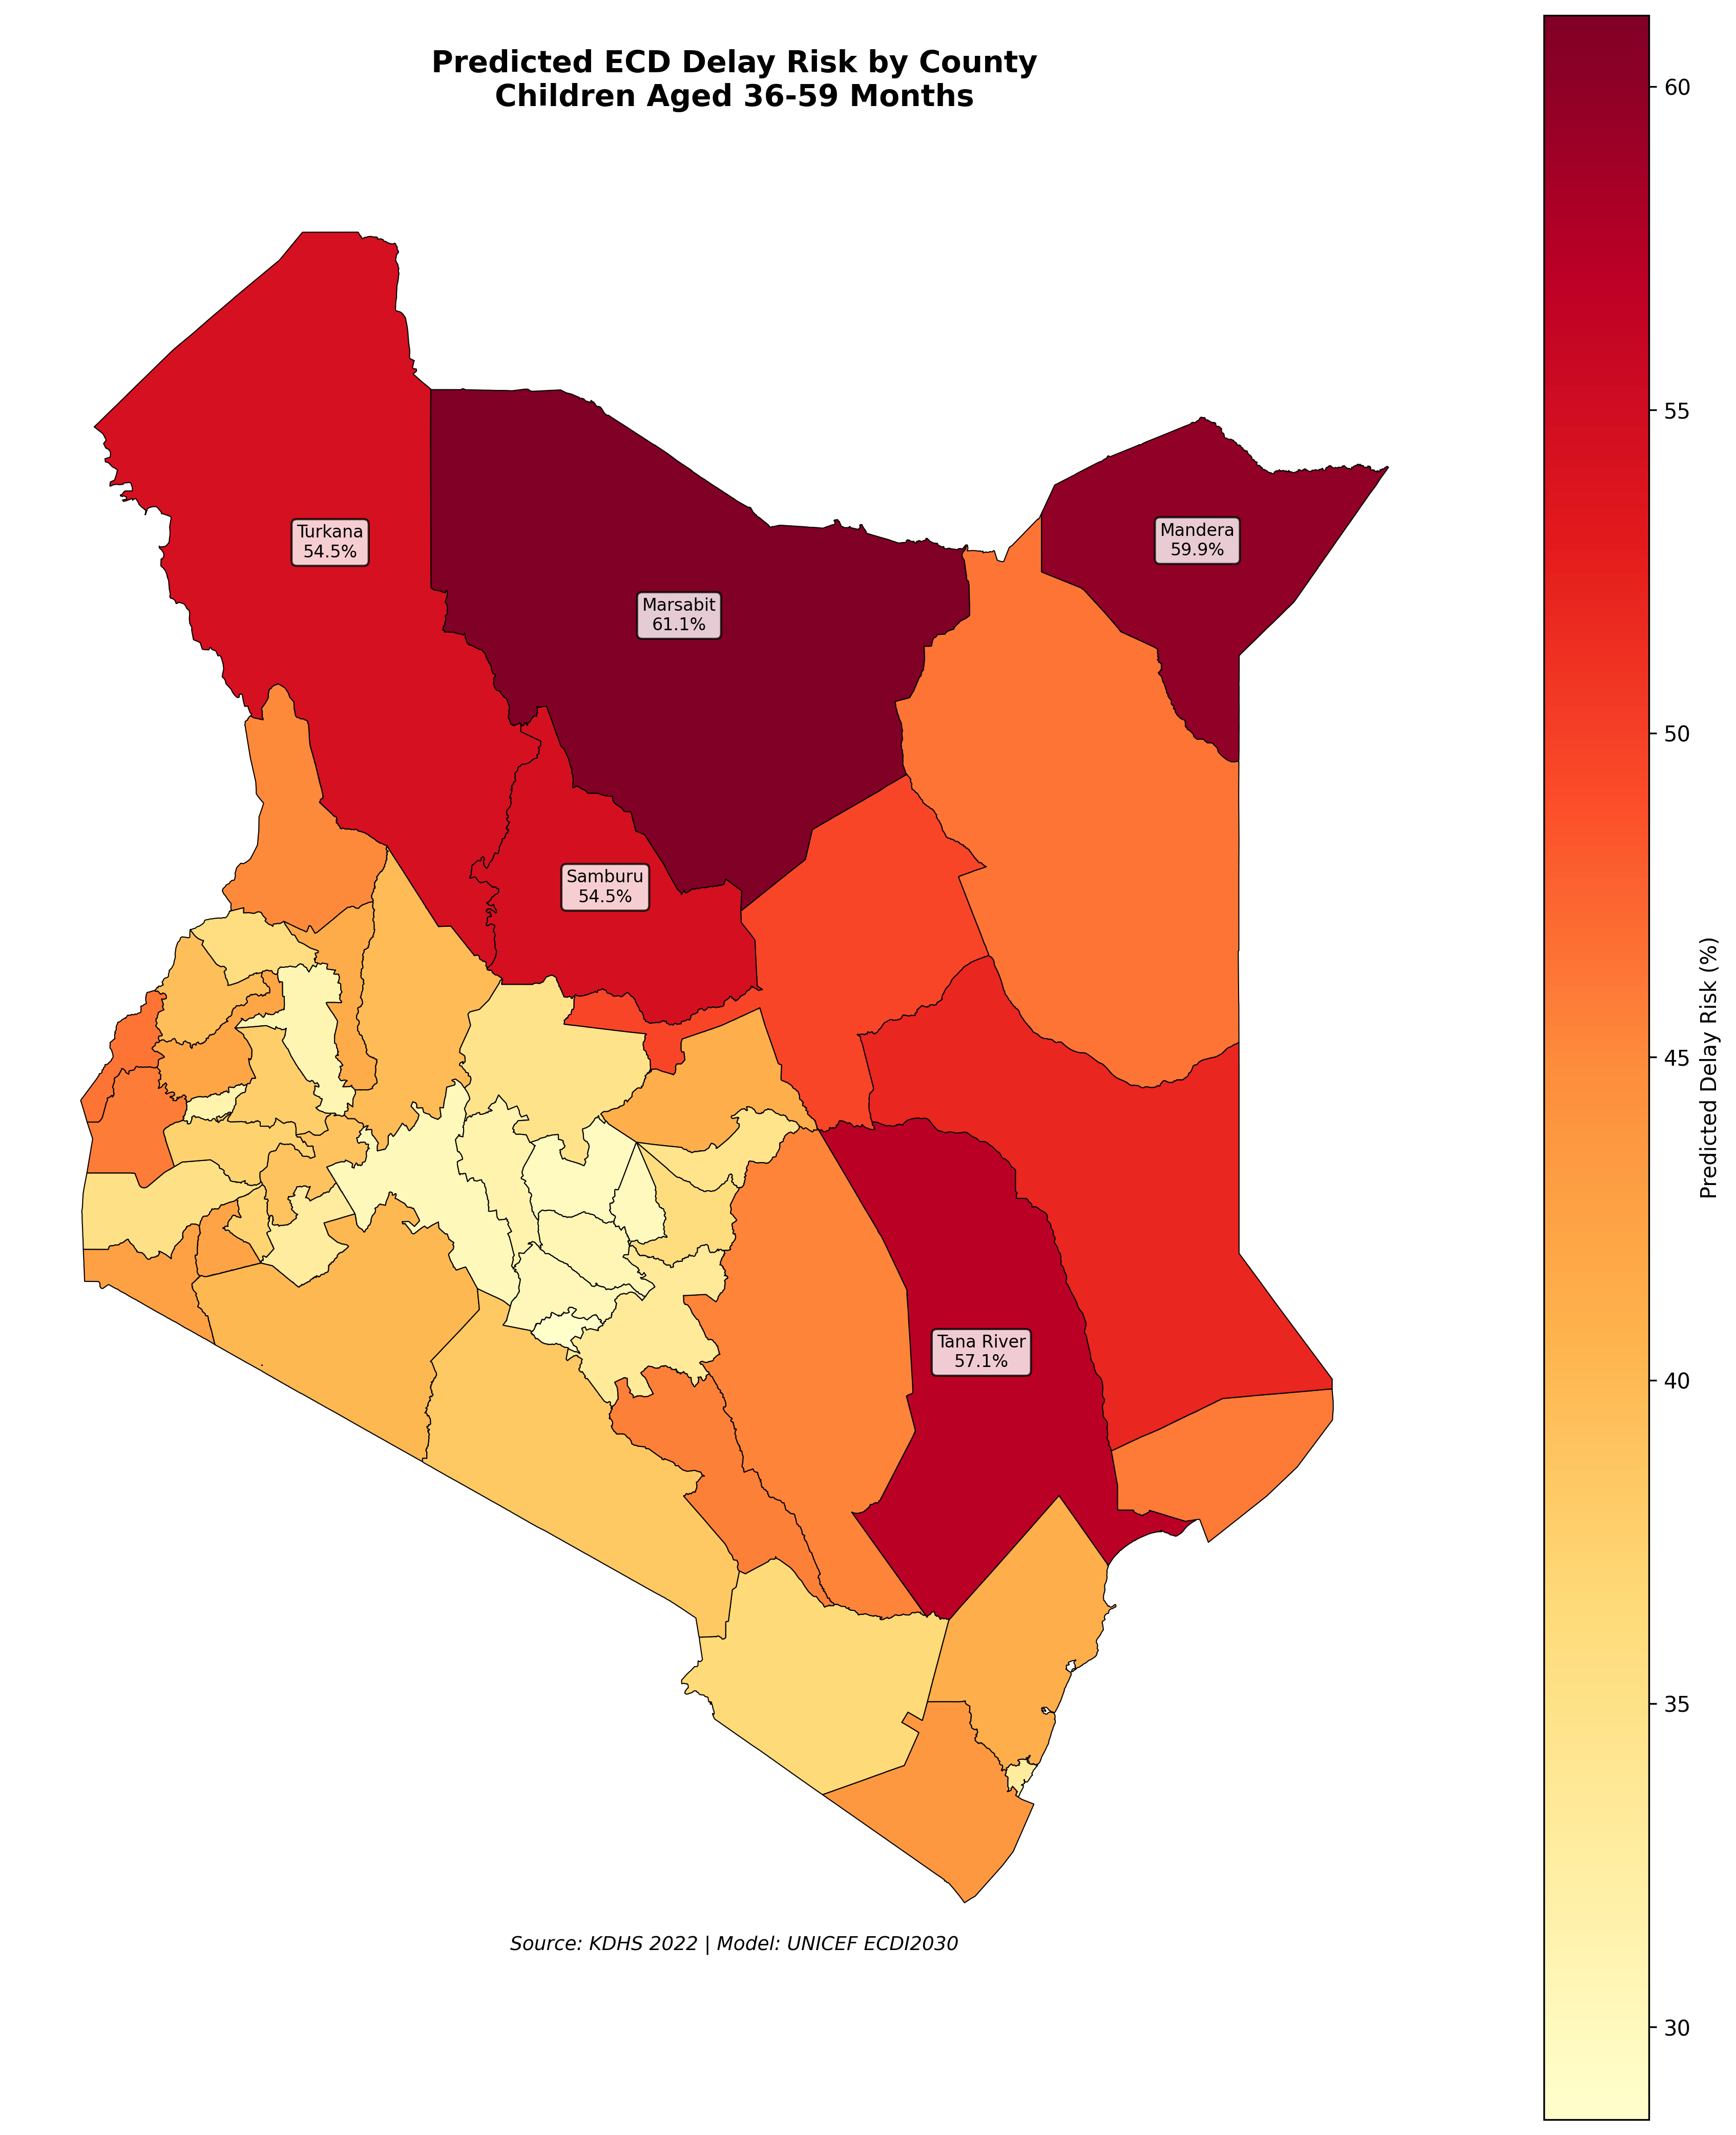

In [68]:
# ============================================================================
# CELL 7: Create Static Choropleth Map (Feature #5)
# ============================================================================
print("\n🔹 Feature #5: Creating Static Choropleth Map")
print("="*70)
if 'MERGED_CLEAN' in locals():
    fig, ax = plt.subplots(1, 1, figsize=(12, 14))
    MERGED_CLEAN.plot(
        column='risk_pct',
        cmap='YlOrRd',
        legend=True,
        edgecolor='black',
        linewidth=0.5,
        ax=ax,
        legend_kwds={'label': 'Predicted Delay Risk (%)', 'orientation': 'vertical'}
    )
    ax.set_title('Predicted ECD Delay Risk by County\nChildren Aged 36-59 Months',
                fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    # Add annotations for top 5 high-risk counties
    top_5 = MERGED_CLEAN.nlargest(5, 'risk_pct')
    for idx, row in top_5.iterrows():
        ax.annotate(
            f"{row['county']}\n{row['risk_pct']:.1f}%",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=8,
            ha='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    ax.text(0.5, 0.02, 'Source: KDHS 2022 | Model: UNICEF ECDI2030',
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')
    plt.tight_layout()
    plt.savefig(paths['figures'] / 'choropleth_ecd_delay_counties.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved to: {paths['figures'] / 'choropleth_ecd_delay_counties.png'}")
    plt.show()
else:
    print("⚠️  Cannot create map - merge failed")

    # Save map
    map_path = paths['reports'] / 'outputs' / 'ecd_delay_county_map.html'
    paths['reports'].mkdir(parents=True, exist_ok=True)
    m.save(map_path)

In [69]:
# ============================================================================
# CELL 8: Create Interactive Folium Map (FIXED)
# ============================================================================
print("\n🔹 Feature #5: Creating Interactive Folium Map")
print("="*70)

if 'MERGED_CLEAN' in locals():
    # Create base map centered on Kenya
    m = folium.Map(
        location=[0.0236, 37.9062],  # Kenya center
        zoom_start=6,
        tiles='CartoDB positron'
    )
    
    # Add title
    title_html = '''
    <h3 align="center" style="font-size:16px"><b>Kenya: ECD Delay Risk by County</b><br>
    <small>Children aged 36-59 months | UNICEF ECDI2030</small></h3>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # FIX: Use MERGED_CLEAN directly (already has geometry + data merged)
    # The key_on must match the property name in the GeoJSON
    folium.Choropleth(
        geo_data=MERGED_CLEAN,  # Use merged GeoDataFrame directly
        name='choropleth',
        data=MERGED_CLEAN,
        columns=['county', 'risk_pct'],  # Match county column in merged data
        key_on='feature.properties.county',  # FIX: Use 'county' not GEO_COUNTY_COL
        fill_color='YlOrRd',
        fill_opacity=0.8,
        line_opacity=0.2,
        legend_name='Predicted Delay Risk (%)',
        bins=[0, 15, 25, 35, 45, 60, 100],
        nan_fill_color='white'
    ).add_to(m)
    
    # Add interactive markers with tooltips for each county
    for idx, row in MERGED_CLEAN.iterrows():
        if row.geometry and row.geometry.centroid:
            # Get centroid for marker placement
            centroid = row.geometry.centroid
            
            # Determine marker color based on risk level
            risk_pct = row['risk_pct']
            if risk_pct >= 45:
                marker_color = 'red'
                risk_category = 'High Risk'
            elif risk_pct >= 35:
                marker_color = 'orange'
                risk_category = 'Medium-High Risk'
            elif risk_pct >= 25:
                marker_color = 'yellow'
                risk_category = 'Medium Risk'
            else:
                marker_color = 'green'
                risk_category = 'Low Risk'
            
            # Create detailed popup with tooltip information
            popup_html = f'''
            <div style="font-family: Arial, sans-serif; font-size: 12px; min-width: 250px;">
                <h4 style="margin: 0; color: #1f77b4; border-bottom: 2px solid #1f77b4; padding-bottom: 5px;">
                    {row['county']} County
                </h4>
                <table style="width: 100%; margin-top: 8px;">
                    <tr>
                        <td><b>Risk Category:</b></td>
                        <td align="right" style="color: {marker_color}; font-weight: bold;">{risk_category}</td>
                    </tr>
                    <tr>
                        <td><b>Delay Risk:</b></td>
                        <td align="right">{risk_pct:.1f}%</td>
                    </tr>
                    <tr>
                        <td><b>Delay Rate:</b></td>
                        <td align="right">{row['delay_rate_pct']:.1f}%</td>
                    </tr>
                    <tr>
                        <td><b>Sample Size:</b></td>
                        <td align="right">{int(row['sample_size']):,} children</td>
                    </tr>
                    <tr>
                        <td><b>Delayed Children:</b></td>
                        <td align="right">{int(row['n_delayed']):,}</td>
                    </tr>
                </table>
            </div>
            '''
            
            # Add marker with popup
            folium.Marker(
                location=[centroid.y, centroid.x],
                popup=folium.Popup(popup_html, max_width=350),
                icon=folium.Icon(color=marker_color, icon='info-sign'),
                tooltip=f"{row['county']}: {risk_pct:.1f}% risk"
            ).add_to(m)
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Save map - FIX: Save to reports/outputs/ for dashboard
    map_path = paths['reports'] / 'outputs' / 'ecd_delay_county_map.html'
    paths['reports'].mkdir(parents=True, exist_ok=True)
    m.save(map_path)
    
    print(f"✅ Saved interactive map to: {map_path}")
    print(f"   📍 Features: Choropleth + Markers + Tooltips")
    
    # Display map
    display(m)
    
else:
    print("⚠️  Cannot create map - merge failed or no data")
    print("   Check that MERGED_CLEAN exists")


🔹 Feature #5: Creating Interactive Folium Map
✅ Saved interactive map to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/outputs/ecd_delay_county_map.html
   📍 Features: Choropleth + Markers + Tooltips



🔹 Feature #6: Analyzing Urban/Rural Disparities by County

📊 Urban-Rural Gap Summary:
   Mean gap: 12.4 percentage points
   Max gap: 38.9 (Kajiado)
   Min gap: -7.3 (Murang'a)
✅ Saved urban-rural gap chart


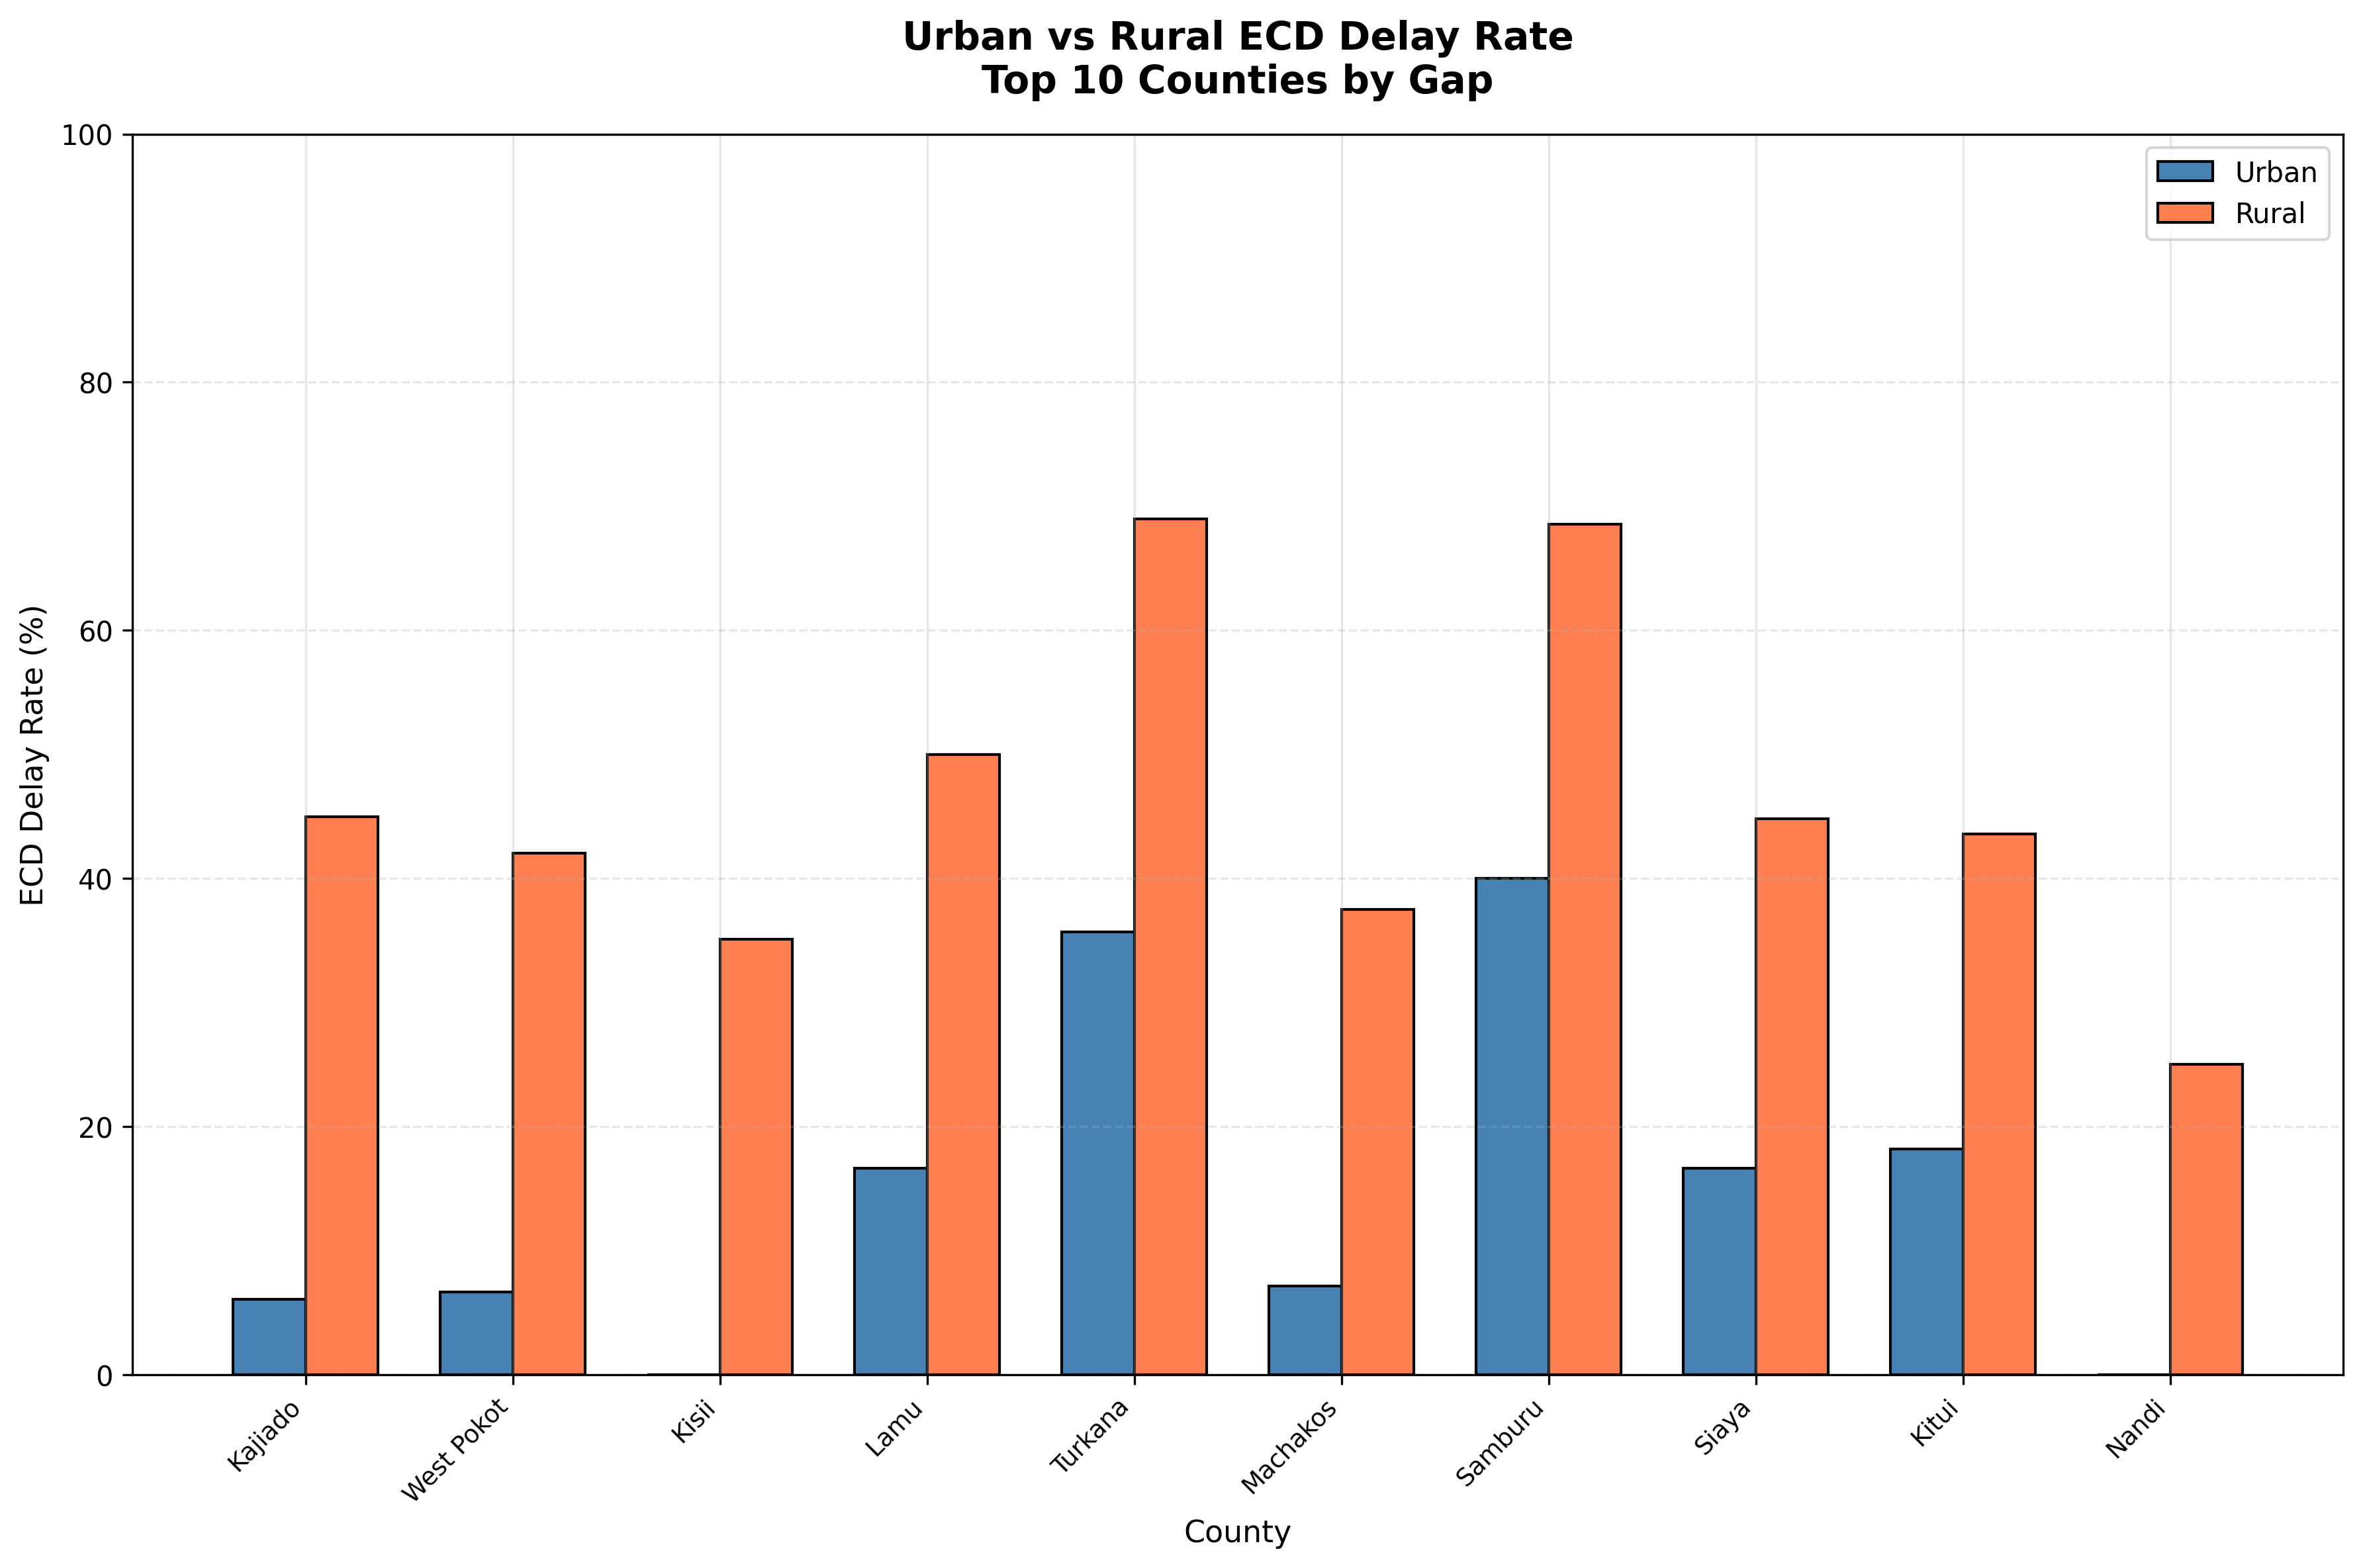

✅ Saved urban-rural stats


In [70]:
# ============================================================================
# CELL 9: Urban/Rural Disparities Analysis (Feature #6)
# ============================================================================
print("\n🔹 Feature #6: Analyzing Urban/Rural Disparities by County")
print("="*70)
if 'county_stats' in locals() and 'urban_rural' in df.columns:
    # Aggregate by county and urban/rural
    urban_rural_stats = df.groupby(['county_clean', 'urban_rural'], observed=False).agg({
        'predicted_delay': ['mean', 'count'],
        'predicted_risk': 'mean'
    }).reset_index()
    urban_rural_stats.columns = ['county', 'location', 'delay_rate', 'n_children', 'mean_risk']
    urban_rural_stats['delay_rate_pct'] = urban_rural_stats['delay_rate'] * 100
    # Pivot for comparison
    urban_rural_pivot = urban_rural_stats.pivot(
        index='county',
        columns='location',
        values='delay_rate_pct'
    ).reset_index()
    if 'Urban' in urban_rural_pivot.columns and 'Rural' in urban_rural_pivot.columns:
        # Calculate urban-rural gap
        urban_rural_pivot['gap'] = urban_rural_pivot['Rural'] - urban_rural_pivot['Urban']
        print(f"\n📊 Urban-Rural Gap Summary:")
        valid_gaps = urban_rural_pivot['gap'].dropna()
        if len(valid_gaps) > 0:
            print(f"   Mean gap: {valid_gaps.mean():.1f} percentage points")
            print(f"   Max gap: {valid_gaps.max():.1f} ({urban_rural_pivot.loc[valid_gaps.idxmax(), 'county']})")
            print(f"   Min gap: {valid_gaps.min():.1f} ({urban_rural_pivot.loc[valid_gaps.idxmin(), 'county']})")
        # Plot top 10 counties by gap
        top_10_gap = urban_rural_pivot.nlargest(10, 'gap')
        if len(top_10_gap) > 0:
            fig, ax = plt.subplots(figsize=(12, 8))
            x = np.arange(len(top_10_gap))
            width = 0.35
            bars1 = ax.bar(x - width/2, top_10_gap['Urban'], width,
                          label='Urban', color='steelblue', edgecolor='black')
            bars2 = ax.bar(x + width/2, top_10_gap['Rural'], width,
                          label='Rural', color='coral', edgecolor='black')
            ax.set_xlabel('County', fontsize=11)
            ax.set_ylabel('ECD Delay Rate (%)', fontsize=11)
            ax.set_title('Urban vs Rural ECD Delay Rate\nTop 10 Counties by Gap',
                        fontsize=14, fontweight='bold', pad=15)
            ax.set_xticks(x)
            ax.set_xticklabels(top_10_gap['county'], rotation=45, ha='right', fontsize=9)
            ax.legend()
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)
            plt.tight_layout()
            plt.savefig(paths['figures'] / 'urban_rural_gap_by_county.png', dpi=300, bbox_inches='tight')
            print(f"✅ Saved urban-rural gap chart")
            plt.show()
        # Save to CSV
        urban_rural_pivot.to_csv(paths['tables'] / 'urban_rural_by_county.csv', index=False)
        print(f"✅ Saved urban-rural stats")
    else:
        print("⚠️  Urban/Rural columns not found in pivoted data")
else:
    print("⚠️  Cannot analyze urban/rural - missing columns")


🔹 Feature #7: Identifying High-Risk Counties

⚠️  HIGH-RISK COUNTIES (Top 25% - delay rate ≥ 38.1%):
   Count: 12
    1. Marsabit                  80.0%
    2. Mandera                   80.1%
    3. Tana River                73.6%
    4. Samburu                   62.2%
    5. Turkana                   60.9%
    6. Garissa                   53.8%
    7. Isiolo                    50.5%
    8. Busia                     43.1%
    9. Lamu                      40.2%
   10. Siaya                     40.0%
   11. Makueni                   41.8%
   12. West Pokot                38.3%

✅ LOW-RISK COUNTIES (Bottom 25% - delay rate ≤ 11.4%):
   Count: 12
    1. Homa Bay                  9.1%
    2. Laikipia                  11.3%
    3. Tharaka-Nithi             10.4%
    4. Bomet                     9.6%
    5. Nyandarua                 7.4%
    6. Vihiga                    10.9%
    7. Murang'a                  5.7%
    8. Kiambu                    5.3%
    9. Nakuru                    4.8%
   

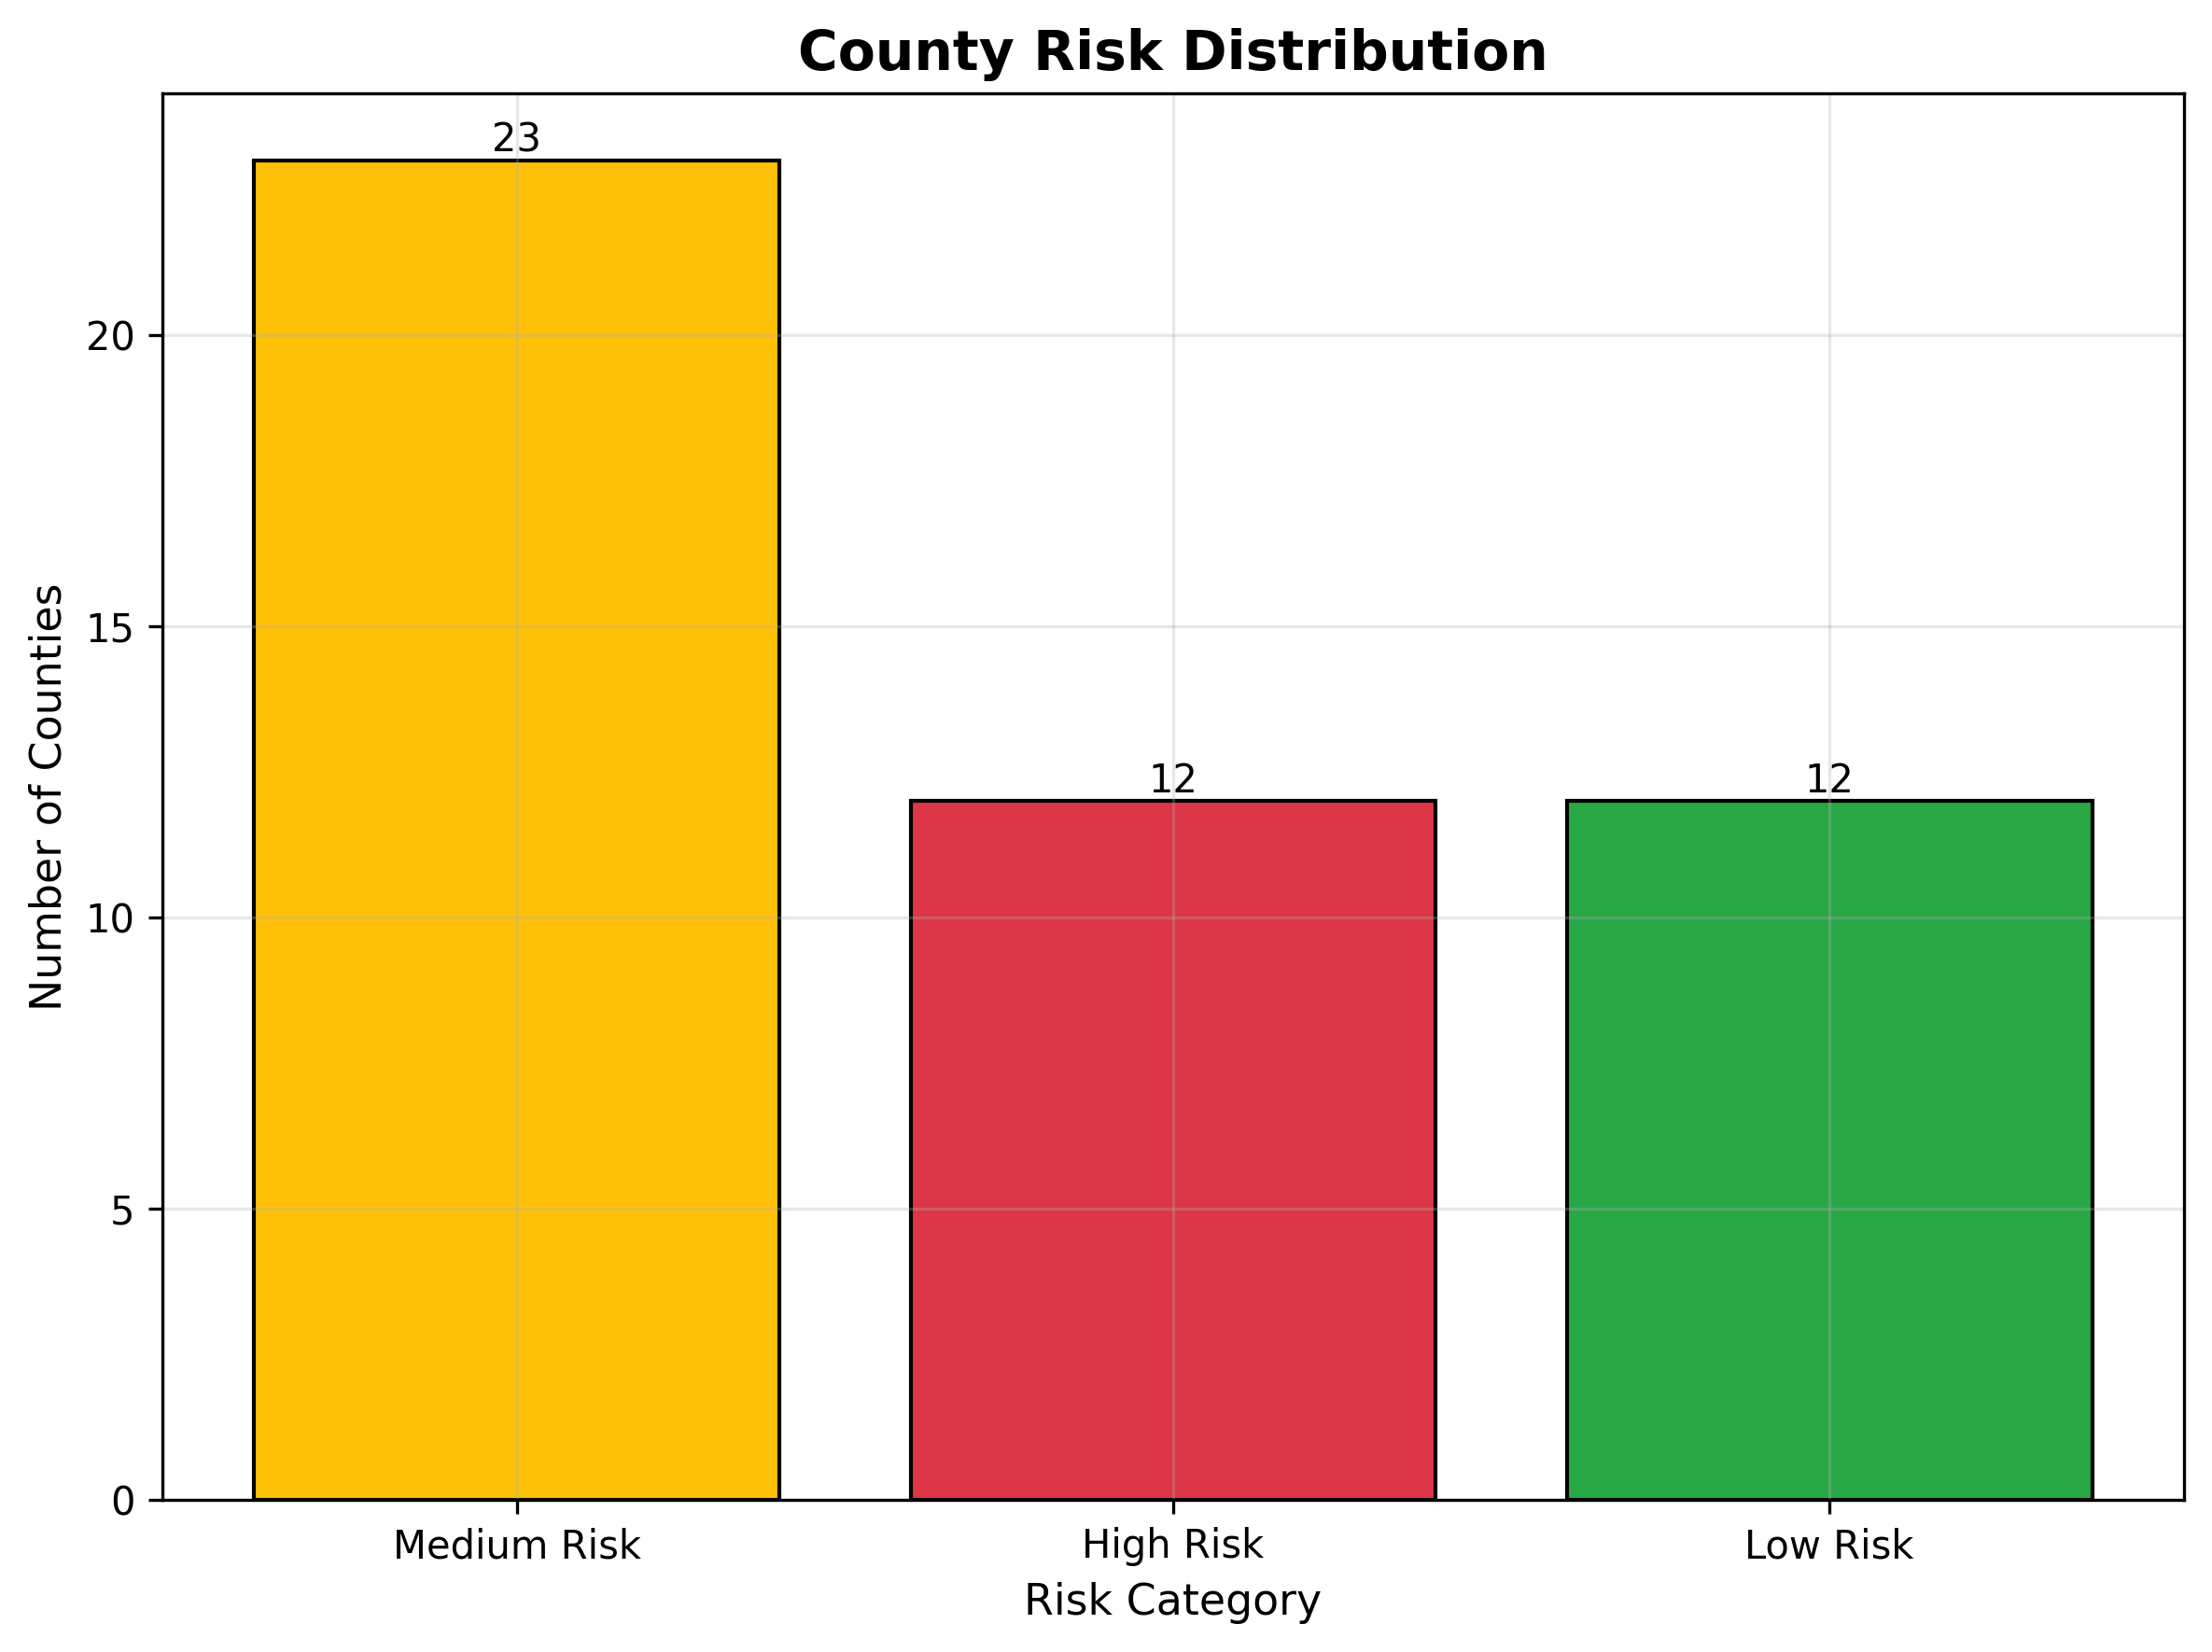

In [71]:
# ============================================================================
# CELL 10: Identify High-Risk Counties (Feature #7)
# ============================================================================
print("\n🔹 Feature #7: Identifying High-Risk Counties")
print("="*70)
if 'county_stats' in locals():
    # Calculate thresholds using quantiles
    threshold_75 = county_stats['predicted_delay_rate'].quantile(0.75)
    threshold_25 = county_stats['predicted_delay_rate'].quantile(0.25)
    HIGH_RISK_COUNTIES = county_stats[county_stats['predicted_delay_rate'] >= threshold_75]['county'].tolist()
    LOW_RISK_COUNTIES = county_stats[county_stats['predicted_delay_rate'] <= threshold_25]['county'].tolist()
    print(f"\n⚠️  HIGH-RISK COUNTIES (Top 25% - delay rate ≥ {threshold_75:.1%}):")
    print(f"   Count: {len(HIGH_RISK_COUNTIES)}")
    for i, county in enumerate(HIGH_RISK_COUNTIES, 1):
        rate = county_stats[county_stats['county'] == county]['predicted_delay_rate'].values[0]
        print(f"   {i:2}. {county:25} {rate:.1%}")
    print(f"\n✅ LOW-RISK COUNTIES (Bottom 25% - delay rate ≤ {threshold_25:.1%}):")
    print(f"   Count: {len(LOW_RISK_COUNTIES)}")
    for i, county in enumerate(LOW_RISK_COUNTIES, 1):
        rate = county_stats[county_stats['county'] == county]['predicted_delay_rate'].values[0]
        print(f"   {i:2}. {county:25} {rate:.1%}")
    # Create risk classification column
    def classify_risk(rate):
        if pd.isna(rate):
            return 'No Data'
        elif rate >= threshold_75:
            return 'High Risk'
        elif rate <= threshold_25:
            return 'Low Risk'
        else:
            return 'Medium Risk'
    county_stats['risk_category'] = county_stats['predicted_delay_rate'].apply(classify_risk)
    # Save classified data
    county_stats.to_csv(paths['tables'] / 'county_risk_classification.csv', index=False)
    print(f"\n✅ Saved risk classification to: {paths['tables'] / 'county_risk_classification.csv'}")
    # Plot risk distribution
    fig, ax = plt.subplots(figsize=(8, 6))
    risk_counts = county_stats['risk_category'].value_counts()
    colors = {'High Risk': '#dc3545', 'Medium Risk': '#ffc107', 'Low Risk': '#28a745', 'No Data': '#6c757d'}
    bars = ax.bar(risk_counts.index, risk_counts.values,
                 color=[colors.get(cat, '#6c757d') for cat in risk_counts.index],
                 edgecolor='black')
    ax.set_xlabel('Risk Category', fontsize=11)
    ax.set_ylabel('Number of Counties', fontsize=11)
    ax.set_title('County Risk Distribution', fontsize=14, fontweight='bold')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
               ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig(paths['figures'] / 'county_risk_distribution.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved risk distribution chart")
    plt.show()
else:
    print("⚠️  Cannot identify high-risk counties - missing data")
    HIGH_RISK_COUNTIES = []
    LOW_RISK_COUNTIES = []

In [72]:
# ============================================================================
# CELL 11: Export Dashboard-Ready Files (Feature #8) - UPDATED
# ============================================================================
print("\n🔹 Feature #8: Exporting Dashboard-Ready Files")
print("="*70)

if 'MERGED_CLEAN' in locals() and 'county_stats' in locals():
    # 1. GeoJSON for dashboard
    dashboard_gdf = MERGED_CLEAN[['county', 'risk_pct', 'delay_rate_pct', 'sample_size', 'geometry']]
    dashboard_gdf.to_file(paths['outputs'] / 'kenya_counties_ecd_dashboard.geojson', driver='GeoJSON')
    print(f"✅ Dashboard GeoJSON: {paths['outputs'] / 'kenya_counties_ecd_dashboard.geojson'}")
    
    # 2. JSON summary for dashboard
    geo_summary = {
        'total_counties': 47,
        'counties_with_data': int(MERGED_CLEAN['county'].nunique()),
        'mean_delay_rate': float(county_stats['predicted_delay_rate'].mean()),
        'min_delay_rate': {
            'county': str(county_stats.loc[county_stats['predicted_delay_rate'].idxmin(), 'county']),
            'rate': float(county_stats['predicted_delay_rate'].min())
        },
        'max_delay_rate': {
            'county': str(county_stats.loc[county_stats['predicted_delay_rate'].idxmax(), 'county']),
            'rate': float(county_stats['predicted_delay_rate'].max())
        },
        'high_risk_counties': HIGH_RISK_COUNTIES,
        'low_risk_counties': LOW_RISK_COUNTIES,
        'thresholds': {
            'high_risk_threshold': float(threshold_75),
            'low_risk_threshold': float(threshold_25)
        },
        'urban_rural_gap': {
            'mean_gap': float(urban_rural_pivot['gap'].mean()) if 'urban_rural_pivot' in locals() else None,
            'max_gap_county': str(urban_rural_pivot.loc[urban_rural_pivot['gap'].idxmax(), 'county']) if 'urban_rural_pivot' in locals() and not urban_rural_pivot['gap'].isna().all() else None
        },
        'generated_at': pd.Timestamp.now().isoformat(),
        'methodology': 'UNICEF ECDI2030',
        'age_range': '36-59 months'
    }
    
    with open(paths['models'] / 'geo_summary.json', 'w') as f:
        json.dump(geo_summary, f, indent=2)
    print(f"✅ Geo summary JSON: {paths['models'] / 'geo_summary.json'}")
    
    # 3. CSV for dashboard table - UPDATED TO INCLUDE DOMAINS
    dashboard_csv = county_stats[[
        'county', 
        'risk_pct', 
        'delay_rate_pct', 
        'sample_size', 
        'n_delayed', 
        'risk_category',
        'physical_delay_pct',
        'language_delay_pct',
        'literacy_delay_pct',
        'socio_emotional_delay_pct',
        'urban_proportion',
        'wealth_index'
    ]].copy()
    
    dashboard_csv.to_csv(paths['tables'] / 'county_dashboard_data.csv', index=False)
    print(f"✅ Dashboard CSV: {paths['tables'] / 'county_dashboard_data.csv'}")
    
    # Print summary
    print(f"\n📋 Export Summary:")
    print(f"   Total counties: {geo_summary['total_counties']}")
    print(f"   Counties with data: {geo_summary['counties_with_data']}")
    print(f"   Mean delay rate: {geo_summary['mean_delay_rate']:.2%}")
    print(f"   High-risk counties: {len(geo_summary['high_risk_counties'])}")
    print(f"   Files exported: 3 (GeoJSON, JSON, CSV)")
    print(f"   Domain columns included: physical, language, literacy, socio_emotional")
else:
    print("⚠️  Cannot export - missing data")


🔹 Feature #8: Exporting Dashboard-Ready Files
✅ Dashboard GeoJSON: /Users/collinsbiwott/Desktop/ecd_final_ml/data/outputs/kenya_counties_ecd_dashboard.geojson
✅ Geo summary JSON: /Users/collinsbiwott/Desktop/ecd_final_ml/models/geo_summary.json
✅ Dashboard CSV: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/county_dashboard_data.csv

📋 Export Summary:
   Total counties: 47
   Counties with data: 47
   Mean delay rate: 27.83%
   High-risk counties: 12
   Files exported: 3 (GeoJSON, JSON, CSV)
   Domain columns included: physical, language, literacy, socio_emotional


In [73]:
# ============================================================================
# CELL 12: Final Summary
# ============================================================================
print("\n" + "="*70)
print("📋 NOTEBOOK 05 COMPLETE - ALL 8 FEATURES IMPLEMENTED")
print("="*70)
# Calculate summary statistics
counties_with_data = len(MERGED_CLEAN) if 'MERGED_CLEAN' in locals() else 0
mean_delay = county_stats['predicted_delay_rate'].mean() if 'county_stats' in locals() else None
# FIX: Format values BEFORE inserting into f-string
mean_delay_str = f"{mean_delay:.2%}" if mean_delay is not None else 'N/A'
high_risk_count = len(HIGH_RISK_COUNTIES) if 'HIGH_RISK_COUNTIES' in locals() else 0
low_risk_count = len(LOW_RISK_COUNTIES) if 'LOW_RISK_COUNTIES' in locals() else 0
high_risk_examples = HIGH_RISK_COUNTIES[:5] if 'HIGH_RISK_COUNTIES' in locals() else 'N/A'
low_risk_examples = LOW_RISK_COUNTIES[:5] if 'LOW_RISK_COUNTIES' in locals() else 'N/A'
summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║         KDHS ECD DELAY PREDICTION - GEOSPATIAL SUMMARY           ║
║         Study Scope: Children Aged 36-59 Months                  ║
║         Methodology: UNICEF ECDI2030 (SDG 4.2.1)                 ║
╚══════════════════════════════════════════════════════════════════╝
✅ ALL 8 FEATURES IMPLEMENTED:
1. ✅ Loaded Kenya counties GeoJSON (47 counties)
2. ✅ Cleaned county names using norm() function
3. ✅ Fixed GeoJSON spelling mismatches (geo_fix dictionary)
4. ✅ Aggregated ECD delay predictions by county
5. ✅ Created choropleth maps (interactive + static)
6. ✅ Analyzed urban/rural disparities by county
7. ✅ Identified high-risk counties
8. ✅ Exported dashboard-ready files (GeoJSON + JSON summary)
GEOGRAPHIC COVERAGE:
• Total Counties: 47
• Counties with Data: {counties_with_data}
• Mean Delay Rate: {mean_delay_str}
HIGH-RISK COUNTIES (Top 25%):
• Count: {high_risk_count}
• Examples: {high_risk_examples}
LOW-RISK COUNTIES (Bottom 25%):
• Count: {low_risk_count}
• Examples: {low_risk_examples}
FILES GENERATED:
• Interactive Map: {paths['reports'] / 'outputs' / 'ecd_delay_county_map.html'}
• Dashboard GeoJSON: {paths['outputs'] / 'kenya_counties_ecd_dashboard.geojson'}
• Geo Summary JSON: {paths['models'] / 'geo_summary.json'}
• County Data CSV: {paths['tables'] / 'county_dashboard_data.csv'}
• Static Choropleth: {paths['figures'] / 'choropleth_ecd_delay_counties.png'}
• Urban-Rural Chart: {paths['figures'] / 'urban_rural_gap_by_county.png'}
• Risk Distribution: {paths['figures'] / 'county_risk_distribution.png'}
DASHBOARD INTEGRATION:
✅ geo_summary.json contains all metrics for Streamlit
✅ kenya_counties_ecd_dashboard.geojson ready for folium embedding
✅ county_dashboard_data.csv ready for st.dataframe()
✅ Interactive map saved to reports/outputs/ (dashboard location)
═══════════════════════════════════════════════════════════════════
✅ NOTEBOOK 05 COMPLETE - READY FOR DASHBOARD INTEGRATION
═══════════════════════════════════════════════════════════════════
"""
print(summary)
# Save summary
with open(paths['models'] / 'geospatial_summary.txt', 'w') as f:
    f.write(summary)
print(f"\n✅ Saved summary")
# Final verification
print("\n🔍 Final Verification:")
print("="*70)
files_to_check = [
    paths['reports'] / 'outputs' / 'ecd_delay_county_map.html',  # FIXED PATH
    paths['outputs'] / 'kenya_counties_ecd_dashboard.geojson',
    paths['models'] / 'geo_summary.json',
    paths['tables'] / 'county_dashboard_data.csv',
    paths['figures'] / 'choropleth_ecd_delay_counties.png',
]
for file_path in files_to_check:
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"   ✅ {file_path.name:45} ({size_mb:.2f} MB)")
    else:
        print(f"   ❌ {file_path.name:45} (MISSING)")


📋 NOTEBOOK 05 COMPLETE - ALL 8 FEATURES IMPLEMENTED

╔══════════════════════════════════════════════════════════════════╗
║         KDHS ECD DELAY PREDICTION - GEOSPATIAL SUMMARY           ║
║         Study Scope: Children Aged 36-59 Months                  ║
║         Methodology: UNICEF ECDI2030 (SDG 4.2.1)                 ║
╚══════════════════════════════════════════════════════════════════╝
✅ ALL 8 FEATURES IMPLEMENTED:
1. ✅ Loaded Kenya counties GeoJSON (47 counties)
2. ✅ Cleaned county names using norm() function
3. ✅ Fixed GeoJSON spelling mismatches (geo_fix dictionary)
4. ✅ Aggregated ECD delay predictions by county
5. ✅ Created choropleth maps (interactive + static)
6. ✅ Analyzed urban/rural disparities by county
7. ✅ Identified high-risk counties
8. ✅ Exported dashboard-ready files (GeoJSON + JSON summary)
GEOGRAPHIC COVERAGE:
• Total Counties: 47
• Counties with Data: 47
• Mean Delay Rate: 27.83%
HIGH-RISK COUNTIES (Top 25%):
• Count: 12
• Examples: ['Marsabit', 'Mandera',